In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from scipy.stats import ttest_ind
from scipy.stats import pearsonr


In [2]:
def plot_scatter_with_r(df, col1, col2, xlabel='X-axis', ylabel='Y-axis', title='Scatter Plot'):
    # Scatter plot
    sns.set(style='whitegrid')
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[col1], y=df[col2], s=50, color='b', label='Data Points', alpha=0.2)

    # Plot 1:1 line
    min_val = min(df[col1].min(), df[col2].min())
    max_val = max(df[col1].max(), df[col2].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='1:1 Line')

    # Calculate Pearson correlation coefficient (R)
    r, _ = pearsonr(df[col1], df[col2])
    
    # Perform t-test between the two columns
    t_stat, p_value = ttest_ind(df[col1], df[col2], equal_var=False)  # Assuming unequal variances

    # Calculate Cohen's d for effect size
    mean1, mean2 = df[col1].mean(), df[col2].mean()
    std1, std2 = df[col1].std(), df[col2].std()
    n1, n2 = len(df[col1]), len(df[col2])
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    cohen_d = (mean1 - mean2) / pooled_std

    # Display R, t-test results, and Cohen's d on the plot
    plt.text(0.75, 0.1, f'R = {r:.2f}', transform=plt.gca().transAxes, fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.5))
    
    plt.text(0.75, 0.05, f't-stat = {t_stat:.2f}, p-value = {p_value:.3f}', transform=plt.gca().transAxes, 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    
    plt.text(0.75, 0.0, f'Cohen\'s d = {cohen_d:.2f}', transform=plt.gca().transAxes, 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

    # Labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    
    # Move the legend to a better position
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show plot
    plt.tight_layout()
    plt.show()

In [3]:
#Read in MUSICA data and process
result_dir = Path('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/')
files_to_open = ['MUSICA_nadp_merged_gridded_daily_timeseries.nc']
                           
# Concatenate directory path with each file name separately
file_paths = [result_dir / file_name for file_name in files_to_open]

# Open multiple netCDF files as a single dataset
nc_daily = xr.open_mfdataset(file_paths, combine='nested')

# Calculate SO4_wet_sum
nc_daily['SO4_wet_sum'] = (nc_daily['so4_a1SFWET'] + nc_daily['so4_a2SFWET'] + nc_daily['so4_a3SFWET'] 
                                + nc_daily['so4_c1SFWET'] + nc_daily['so4_c2SFWET'] + nc_daily['so4_c3SFWET']) * -1

# Calculate NO3_wet and correct for molar mass
nc_daily['NO3_wet'] = nc_daily['WD_HNO3'] * -1 * 0.984006

# Calculate NH4_wet and correct for data sign
nc_daily['WD_NH4_corr'] = xr.where(nc_daily['WD_NH4'] > 0, 0, nc_daily['WD_NH4'])

#Calculate total precipitation
nc_daily['PRECC_mm'] = nc_daily['PRECC']* (86400*1000) # seconds to days and m to mm = mm/d
nc_daily['PRECL_mm'] = nc_daily['PRECL']* (86400*1000)
nc_daily['PREC_tot_mm'] = nc_daily['PRECC_mm']  + nc_daily['PRECL_mm']

#Calculate BC wet sum
nc_daily['BC_wet_sum'] = (nc_daily['bc_a1SFWET'] + nc_daily['bc_a4SFWET'] + nc_daily['bc_c1SFWET'] 
                                + nc_daily['bc_c4SFWET']) * -1

#Calculate SOA and POM sum
nc_daily['SOA_POM_wet_sum'] = (nc_daily['soa1_a1SFWET'] + nc_daily['soa1_a2SFWET'] + nc_daily['soa1_c1SFWET'] 
                             + nc_daily['soa1_c2SFWET'] + nc_daily['soa2_a1SFWET'] + nc_daily['soa2_a2SFWET'] 
                             + nc_daily['soa2_c1SFWET'] +  nc_daily['soa2_c2SFWET'] + nc_daily['soa3_a1SFWET'] 
                             + nc_daily['soa3_a2SFWET'] + nc_daily['soa3_c1SFWET'] + nc_daily['soa3_c2SFWET'] 
                             + nc_daily['soa4_a1SFWET'] + nc_daily['soa4_a2SFWET'] + nc_daily['soa4_c1SFWET'] 
                             + nc_daily['soa4_c2SFWET'] + nc_daily['soa5_a1SFWET'] + nc_daily['soa5_a2SFWET'] 
                             + nc_daily['soa5_c1SFWET'] + nc_daily['soa5_c2SFWET'] + nc_daily['pom_a1SFWET']
                             + nc_daily['pom_a4SFWET'] + nc_daily['pom_c1SFWET'] + nc_daily['pom_c4SFWET']) * -1

#Calculate DOC sum (BC + SOA + POM)
nc_daily['DOC_wet_sum'] = nc_daily['BC_wet_sum']  + nc_daily['SOA_POM_wet_sum']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
nc_daily = nc_daily.apply(lambda x: x * conversions if x.name in ['SO4_wet_sum', 'WD_NH4_corr', 'NO3_wet', 'DOC_wet_sum'] else x)
nc_daily = nc_daily[['lat', 'lon', 'siteId', 'area', 'BC_wet_sum', 'SOA_POM_wet_sum', 'DOC_wet_sum', 'PREC_tot_mm', 'SO4_wet_sum', 'WD_NH4_corr', 'NO3_wet']]
nc_daily

<xarray.Dataset>
Dimensions:          (time: 729, ncol: 415)
Coordinates:
  * time             (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2018-12-30
  * ncol             (ncol) int64 167072 51725 168858 ... 166062 141507 150484
Data variables:
    lat              (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    lon              (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    siteId           (ncol) object dask.array<chunksize=(415,), meta=np.ndarray>
    area             (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    BC_wet_sum       (time, ncol) float32 dask.array<chunksize=(729, 415), meta=np.ndarray>
    SOA_POM_wet_sum  (time, ncol) float32 dask.array<chunksize=(729, 415), meta=np.ndarray>
    DOC_wet_sum      (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    PREC_tot_mm      (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    SO4_wet_sum      (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    WD_NH4_corr      (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>
    NO3_wet          (time, ncol) float64 dask.array<chunksize=(729, 415), meta=np.ndarray>

In [4]:
#Turn nc_daily_nadp xarray into a pandas dataframe with similar attributes to the NADP dataset
mod_musica = nc_daily.to_dataframe().reset_index()
mod_musica = mod_musica.replace(-0.0, 0)
mod_musica = mod_musica.rename(columns = {'time': 'model_time', 'SO4_wet_sum': 'MUS_Mod_SO4_mgm2', 'WD_NH4_corr': 'MUS_Mod_NH4_mgm2', 
                                          'NO3_wet':'MUS_Mod_NO3_mgm2', 'DOC_wet_sum': 'MUS_Mod_DOC_mgm2', 'BC_wet_sum': 'MUS_Mod_BC_mgm2', 
                                          'SOA_POM_wet_sum': 'MUS_Mod_SOA_POM_mgm2'})

# change the unit conversion of Mod_NH4_mgm2 because it didn't work in above code?
mod_musica['MUS_Mod_NH4_mgm2'] = mod_musica['MUS_Mod_NH4_mgm2'] * -1 #negative to positive, for some reason this did not work in above conversion code
mod_musica['MUS_Mod_NH4_mgm2'] = mod_musica['MUS_Mod_NH4_mgm2'].replace(-0.0, 0.0)

#IMPORTANT STEP: change the time to one day prior (model writes time at end of current day)
mod_musica['time'] = pd.to_datetime(mod_musica['model_time'],format='%Y-%m-%d')+DateOffset(days=-1)

mod_musica

,model_time,ncol,lat,lon,siteId,area,MUS_Mod_BC_mgm2,MUS_Mod_SOA_POM_mgm2,MUS_Mod_DOC_mgm2,PREC_tot_mm,MUS_Mod_SO4_mgm2,MUS_Mod_NH4_mgm2,MUS_Mod_NO3_mgm2,time
0,2017-01-01,167072,50.639425,248.354064,AB32,0.000007,2.031601e-14,2.019839e-13,0.019207,4.567812,0.044528,1.889482e-02,3.094687,2016-12-31
1,2017-01-01,51725,60.823700,248.828346,AB34,0.000029,2.838477e-15,2.771199e-14,0.002640,0.728992,0.002584,9.988853e-16,0.006340,2016-12-31
2,2017-01-01,168858,51.195778,248.962827,AB36,0.000001,2.401363e-14,2.571507e-13,0.024293,3.219753,0.086692,1.126914e-02,0.631660,2016-12-31
3,2017-01-01,3193,72.762243,234.706634,AK01,0.000052,5.955684e-18,7.164994e-17,0.000007,0.530774,0.000013,0.000000e+00,0.001671,2016-12-31
4,2017-01-01,3193,72.762243,234.706634,AK02,0.000052,5.955684e-18,7.164994e-17,0.000007,0.530774,0.000013,0.000000e+00,0.001671,2016-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302530,2018-12-30,124049,35.734883,276.407017,TN11,0.000003,5.553094e-18,4.999986e-17,0.000005,0.033066,0.000095,5.763388e-04,0.019421,2018-12-29
302531,2018-12-30,100866,28.483179,262.339314,TX03,0.000003,2.818292e-13,3.532342e-12,0.329544,0.690617,0.524900,1.398318e-01,1.871701,2018-12-29
302532,2018-12-30,166062,47.798792,236.020964,WA14,0.000003,3.475861e-13,2.611769e-12,0.255688,76.982043,1.725800,1.198780e-01,2.715789,2018-12-29
302533,2018-12-30,141507,38.937720,279.101951,WV05,0.000003,1.459382e-15,1.391707e-14,0.001329,0.009155,0.002784,3.212124e-02,0.538719,2018-12-29


In [5]:
#Read in the panda dfs from the global model
glob_inorg = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/SO4_NO3_NH4_global20172018_cleaned_nadpsitemerged.csv', parse_dates = ['time'])
glob_precip = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Precip_global20172018_cleaned_nadpsitemerged.csv', parse_dates = ['time'])
glob_doc = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/DOCproxy_global20172018_cleaned_nadpsitemerged.csv',  parse_dates = ['time'])


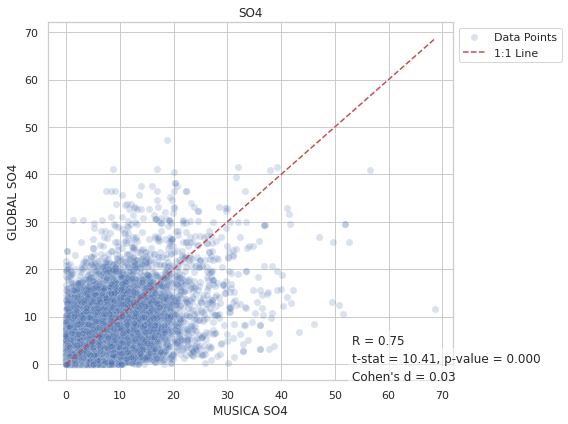

1.048171967888168
0.9881766010525044


In [6]:
#Create scatter plots for SO4
mus_so4 = mod_musica[['time', 'siteId', 'MUS_Mod_SO4_mgm2']]
glob_so4 = glob_inorg[['time', 'siteId', 'Mod_SO4_mgm2']]
so4_musglob = pd.merge(mus_so4, glob_so4, on = ['siteId', 'time'], how = 'left')
so4_musglob.dropna(inplace = True)

plot_scatter_with_r(so4_musglob, 'MUS_Mod_SO4_mgm2', 'Mod_SO4_mgm2', xlabel='MUSICA SO4', ylabel='GLOBAL SO4', title='SO4')
print(so4_musglob.MUS_Mod_SO4_mgm2.mean())
print(so4_musglob.Mod_SO4_mgm2.mean())


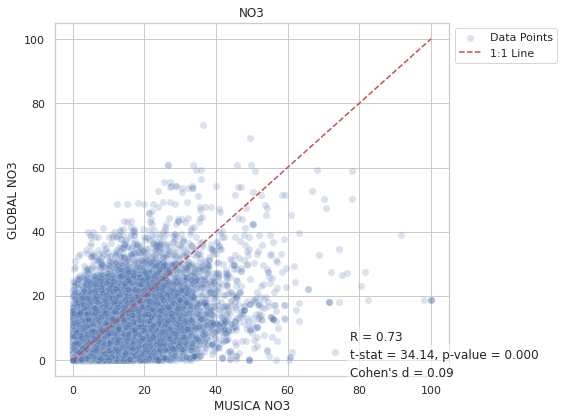

2.4899574617522062
2.1188406154875357


In [7]:
#Create scatter plots for NO3
mus_no3 = mod_musica[['time', 'siteId', 'MUS_Mod_NO3_mgm2']]
glob_no3 = glob_inorg[['time', 'siteId', 'Mod_NO3_mgm2']]
no3_musglob = pd.merge(mus_no3, glob_no3, on = ['siteId', 'time'], how = 'left')
no3_musglob.dropna(inplace = True)

plot_scatter_with_r(no3_musglob, 'MUS_Mod_NO3_mgm2', 'Mod_NO3_mgm2', xlabel='MUSICA NO3', ylabel='GLOBAL NO3', title='NO3')
print(no3_musglob.MUS_Mod_NO3_mgm2.mean())
print(no3_musglob.Mod_NO3_mgm2.mean())

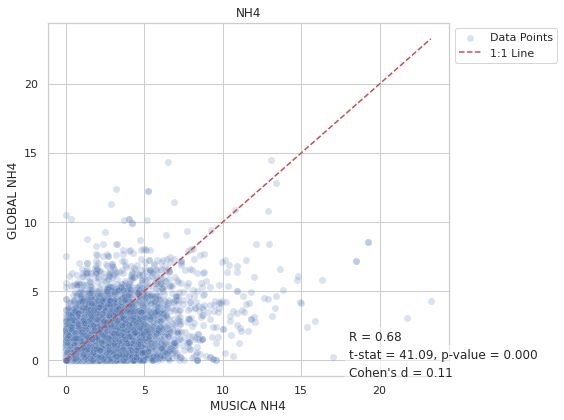

0.24155831718949264
0.18490969456062925


In [8]:
#Create scatter plots for NH4
mus_nh4 = mod_musica[['time', 'siteId', 'MUS_Mod_NH4_mgm2']]
glob_nh4 = glob_inorg[['time', 'siteId', 'Mod_NH4_mgm2']]
nh4_musglob = pd.merge(mus_nh4, glob_nh4, on = ['siteId', 'time'], how = 'left')
nh4_musglob.dropna(inplace = True)

plot_scatter_with_r(nh4_musglob, 'MUS_Mod_NH4_mgm2', 'Mod_NH4_mgm2', xlabel='MUSICA NH4', ylabel='GLOBAL NH4', title='NH4')
print(nh4_musglob.MUS_Mod_NH4_mgm2.mean())
print(nh4_musglob.Mod_NH4_mgm2.mean())

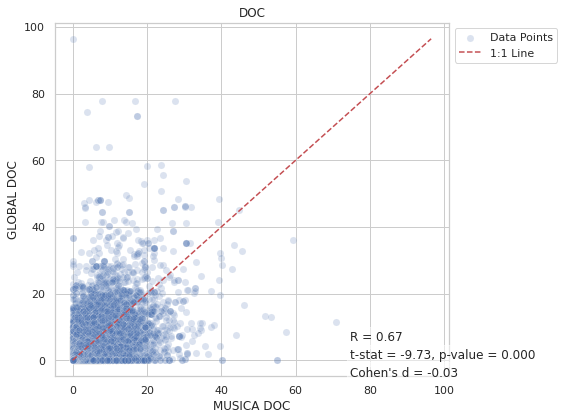

0.9637925710791652
1.043255587603899


In [9]:
#Create scatter plots for DOC
mus_doc = mod_musica[['time', 'siteId', 'MUS_Mod_DOC_mgm2']]
glob_doc = glob_doc[['time', 'siteId', 'Mod_SOA_POM_BC_mgm2']]
doc_musglob = pd.merge(mus_doc, glob_doc, on = ['siteId', 'time'], how = 'left')
doc_musglob.dropna(inplace = True)

plot_scatter_with_r(doc_musglob, 'MUS_Mod_DOC_mgm2', 'Mod_SOA_POM_BC_mgm2', xlabel='MUSICA DOC', ylabel='GLOBAL DOC', title='DOC')
print(doc_musglob.MUS_Mod_DOC_mgm2.mean())
print(doc_musglob.Mod_SOA_POM_BC_mgm2.mean())

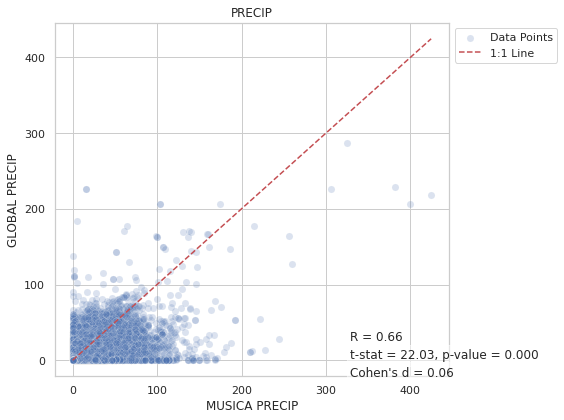

3.032054659010927
2.6079895791592236


In [10]:
#Create scatter plots for PRECIP
mus_precip = mod_musica[['time', 'siteId', 'PREC_tot_mm']]
glob_precip = glob_precip[['time', 'siteId', 'PREC_tot_mm']]
precip_musglob = pd.merge(mus_precip, glob_precip, on = ['siteId', 'time'], how = 'left')
precip_musglob.dropna(inplace = True)

plot_scatter_with_r(precip_musglob, 'PREC_tot_mm_x', 'PREC_tot_mm_y', xlabel='MUSICA PRECIP', ylabel='GLOBAL PRECIP', title='PRECIP')
print(precip_musglob.PREC_tot_mm_x.mean())
print(precip_musglob.PREC_tot_mm_y.mean())